In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of charachers and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
# build the "lookup table" 'C'
# 27 characters, embedded in a lower dimensional space
C = torch.randn((27, 2))

In [8]:
C

tensor([[-7.5389e-01,  2.6966e-01],
        [ 1.3951e+00, -3.5825e-01],
        [ 4.1599e-03, -1.7078e-01],
        [ 1.4708e+00, -1.8900e+00],
        [-9.6941e-01, -1.0545e+00],
        [ 9.5283e-01, -2.9817e-01],
        [-1.4791e+00,  5.8239e-01],
        [ 9.0081e-01, -1.6137e+00],
        [ 5.2392e-01,  1.1315e+00],
        [ 3.2967e-01,  7.2486e-01],
        [-1.2184e+00,  4.5701e-01],
        [-3.1967e-01, -7.6264e-01],
        [-2.3169e+00,  8.1230e-01],
        [ 3.7757e-01,  4.6705e-02],
        [ 1.6160e+00, -2.0790e-01],
        [ 4.7882e-01,  9.4395e-01],
        [-4.7330e-01, -2.0884e-02],
        [-2.7215e+00,  1.9506e-01],
        [ 2.1232e-01, -8.5661e-01],
        [ 2.9502e-01, -7.0983e-01],
        [-1.4094e-01,  2.0127e+00],
        [ 5.7110e-01, -1.0240e+00],
        [-1.4086e-01, -4.1756e-01],
        [-2.3154e-01,  7.4607e-01],
        [ 1.0090e+00, -1.9095e-03],
        [ 1.5118e+00, -1.3638e+00],
        [ 1.2148e+00,  9.9812e-01]])

In [9]:
# 2 ways to think about indexing into C
# initial:

In [10]:
C[5]

tensor([ 0.9528, -0.2982])

In [11]:
# second:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.9528, -0.2982])

In [12]:
# can think of the indexing as a first layer of the neural net
# there is no non-linearity (tanh), weight matrix is C
# encoding integers into one_hot and feeding in
# this 'first layer' embeds them

In [13]:
# different ways of indexing
C[5]

tensor([ 0.9528, -0.2982])

In [14]:
C[[5, 6, 7]]

tensor([[ 0.9528, -0.2982],
        [-1.4791,  0.5824],
        [ 0.9008, -1.6137]])

In [15]:
C[torch.tensor([5, 6, 7, 7, 7])]

tensor([[ 0.9528, -0.2982],
        [-1.4791,  0.5824],
        [ 0.9008, -1.6137],
        [ 0.9008, -1.6137],
        [ 0.9008, -1.6137]])

In [16]:
# index w/ multidimensional vectors
C[X]

tensor([[[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697]],

        [[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.9528, -0.2982]],

        [[-0.7539,  0.2697],
         [ 0.9528, -0.2982],
         [ 0.3776,  0.0467]],

        [[ 0.9528, -0.2982],
         [ 0.3776,  0.0467],
         [ 0.3776,  0.0467]],

        [[ 0.3776,  0.0467],
         [ 0.3776,  0.0467],
         [ 1.3951, -0.3582]],

        [[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697]],

        [[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.4788,  0.9440]],

        [[-0.7539,  0.2697],
         [ 0.4788,  0.9440],
         [-2.3169,  0.8123]],

        [[ 0.4788,  0.9440],
         [-2.3169,  0.8123],
         [ 0.3297,  0.7249]],

        [[-2.3169,  0.8123],
         [ 0.3297,  0.7249],
         [-0.1409, -0.4176]],

        [[ 0.3297,  0.7249],
         [-0.1409, -0.4176],
         [ 0.3297,  0.7249]],

        [[-0.1409, -0

In [17]:
C[X].shape

torch.Size([32, 3, 2])

In [18]:
X[13,2]

tensor(1)

In [19]:
C[X][13,2]

tensor([ 1.3951, -0.3582])

In [20]:
C[1]

tensor([ 1.3951, -0.3582])

In [21]:
# in summary pytorch indexing is awesom!

In [22]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [23]:
# construct hidden layer
# weights initialized randomly, 6 dimensions for (3 * 2) from input shape above
# num neurons is up to us, 100 for example
W1 = torch.randn((6, 100))
# biases also initialized randomly
b1 = torch.randn(100)

In [24]:
# need to 'concatenate' inputs in [32, 3, 2] 
# so we can mult by [6, 100]
# as in emb @ W1 + b1

In [25]:
# torch.cat does just that
# this will not generalize if we change block size
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [26]:
# torch.unbind does what we need
# pass in the embedding and specify a dimension
# returns a tuple of slices along a given dimension, already without it
torch.unbind(emb, 1)

(tensor([[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.9528, -0.2982],
         [ 0.3776,  0.0467],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.4788,  0.9440],
         [-2.3169,  0.8123],
         [ 0.3297,  0.7249],
         [-0.1409, -0.4176],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 1.3951, -0.3582],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.3297,  0.7249],
         [ 0.2950, -0.7098],
         [ 1.3951, -0.3582],
         [ 0.0042, -0.1708],
         [ 0.9528, -0.2982],
         [-2.3169,  0.8123],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0.2950, -0.7098],
         [ 0.4788,  0.9440],
         [-0.4733, -0.0209],
         [ 0.5239,  1.1315]]),
 tensor([[-0.7539,  0.2697],
         [-0.7539,  0.2697],
         [ 0

In [27]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [28]:
# there is still another better way!

In [29]:
# ASIDE>>>
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [30]:
a.shape

torch.Size([18])

In [31]:
a.view(2, 9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [32]:
a.view(9, 2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [33]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [34]:
# tensor always represented in computer memory as 1-dimensional vector
a.storage()

/tmp/ipykernel_8468/1532441162.py:2: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [35]:
emb.view(32, 6)

tensor([[-0.7539,  0.2697, -0.7539,  0.2697, -0.7539,  0.2697],
        [-0.7539,  0.2697, -0.7539,  0.2697,  0.9528, -0.2982],
        [-0.7539,  0.2697,  0.9528, -0.2982,  0.3776,  0.0467],
        [ 0.9528, -0.2982,  0.3776,  0.0467,  0.3776,  0.0467],
        [ 0.3776,  0.0467,  0.3776,  0.0467,  1.3951, -0.3582],
        [-0.7539,  0.2697, -0.7539,  0.2697, -0.7539,  0.2697],
        [-0.7539,  0.2697, -0.7539,  0.2697,  0.4788,  0.9440],
        [-0.7539,  0.2697,  0.4788,  0.9440, -2.3169,  0.8123],
        [ 0.4788,  0.9440, -2.3169,  0.8123,  0.3297,  0.7249],
        [-2.3169,  0.8123,  0.3297,  0.7249, -0.1409, -0.4176],
        [ 0.3297,  0.7249, -0.1409, -0.4176,  0.3297,  0.7249],
        [-0.1409, -0.4176,  0.3297,  0.7249,  1.3951, -0.3582],
        [-0.7539,  0.2697, -0.7539,  0.2697, -0.7539,  0.2697],
        [-0.7539,  0.2697, -0.7539,  0.2697,  1.3951, -0.3582],
        [-0.7539,  0.2697,  1.3951, -0.3582, -0.1409, -0.4176],
        [ 1.3951, -0.3582, -0.1409, -0.4

In [36]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [37]:
# Finally
# h = emb.view(emb.shape[0], 6) @ W1 + b1
# shape can be inferred if you use '-1' as a placeholder
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [38]:
h

tensor([[ 0.7680,  0.6374, -0.8616,  ..., -0.1941,  0.9726, -0.2676],
        [-0.6288, -0.6481, -0.7690,  ..., -0.9984,  0.9833, -0.7803],
        [-0.8811,  0.4669, -0.9784,  ..., -0.9986,  0.9920, -0.0195],
        ...,
        [ 0.9334,  0.3552,  0.6136,  ..., -0.1345,  0.7520, -0.4773],
        [-0.9830,  0.9132, -0.4354,  ..., -0.9984,  0.9993,  0.9842],
        [-0.9779, -0.8036,  0.5969,  ..., -0.9999,  0.9999,  0.4608]])

In [39]:
h.shape

torch.Size([32, 100])

In [40]:
# Final layer
# 100 inputs, 27 outputs
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [41]:
logits = h @ W2 + b2

In [42]:
logits.shape

torch.Size([32, 27])

In [43]:
counts = logits.exp()

In [44]:
prob = counts / counts.sum(1, keepdim=True)

In [45]:
prob.shape

torch.Size([32, 27])

In [46]:
# normalized probability sums to 1.0 
prob[0].sum()

tensor(1.)

In [47]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [48]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [49]:
# the following indexes into the probabilities and gets the probability
# associated with the correct output 'Y'
prob[torch.arange(32), Y]

tensor([5.6551e-08, 3.4048e-11, 3.0915e-08, 2.9487e-06, 4.3674e-04, 7.4191e-06,
        1.9712e-07, 3.6155e-14, 2.4707e-10, 1.1927e-09, 7.5295e-05, 1.2712e-03,
        2.8412e-08, 4.3097e-07, 9.4761e-10, 8.1350e-11, 5.6622e-11, 9.7507e-01,
        3.5040e-03, 1.5899e-10, 1.3421e-08, 2.4883e-11, 1.7335e-07, 5.0097e-10,
        1.4254e-12, 1.6079e-01, 5.5710e-04, 7.1139e-11, 2.8263e-06, 1.1663e-08,
        2.0329e-01, 3.4801e-09])

In [50]:
# neg log likelihood loss
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.0958)

In [51]:
# ------------------- CONDENSED VERSION OF EVERYTHING -----------------#

In [52]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [53]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [122]:
# build the dataset

def build_dataset(words):
    block_size = 5 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
    
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 5]) torch.Size([182580])
torch.Size([22767, 5]) torch.Size([22767])
torch.Size([22799, 5]) torch.Size([22799])


In [130]:
# easiest way to scale up is to increase neurons in hidden layer
# # from 100 to 300
# Scaling up embedding vector from 2 to 10
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((50, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [131]:
sum(p.nelement() for p in parameters) # number of parameters in total

15897

In [132]:
for p in parameters:
    p.requires_grad = True

In [58]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [96]:
lri = []
lossi = []
stepi = []

In [ ]:

for i in range(200000):

    # minibatch construct
    # this index is used in X AND Y
    ix = torch.randint(0, Xtr.shape[0], (64,))
    
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 50) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # this is classification and there is a dedicated function in pytorch to do the same more efficiently
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update|
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    
# print(loss.item())

In [ ]:
# Additional tweaks made after end:
# Increase batch size from 32 to 64 
# First pass loss Dev/Train: 2.149/2.116

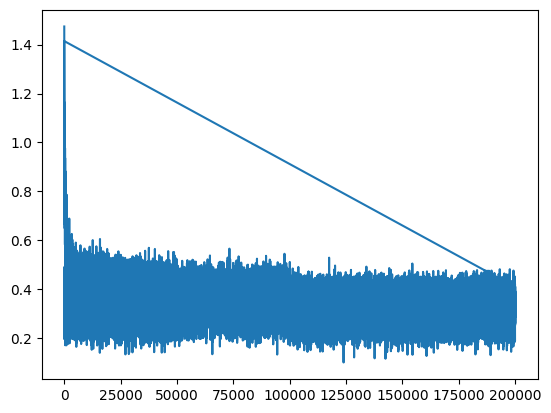

In [117]:
plt.plot(stepi, lossi)

In [130]:
# because we have ~3200 parameters and only 32 examples, we are overfitting the data
# so go back and use all the words, not just first 5

In [115]:
# Now each iteration is doing forward, backward, and update on all inputs
# standard practice is to bath data and do smaller fwd, back, upd passes on different batches

In [117]:
# create integers that index into our dataset
# so each time this is called in the loop, we will get a new batch of 32 indices to use as our batch
torch.randint(0, X.shape[0], (32,))

tensor([139747, 162835, 206851, 210553, 167227,  32507,  61418, 215950, 166518,
         80017,  62247, 191046, 124598, 167583, 139201,   9674, 142902,  72847,
         62108, 115367,  31446,   8740, 127842,  91679,  87169,  35288, 157102,
         60828, 224282, 157732,   1064, 134035])

In [127]:
# much better to have an approximate gradient (as we do when using the minibatch)
# and take more steps
# than it is to evaluate the exact gradient, with fewer steps

In [118]:
# Loss for the dev dataset:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1490, grad_fn=<NllLossBackward0>)

In [119]:
# Loss for the tr dataset:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1162, grad_fn=<NllLossBackward0>)

In [ ]:
# losses are about equal between training data amd dev data
# means network is small and we can expect to improve by scaling up size


In [142]:
# -0.1 in the update step is a guess
# are we stepping too fast or too slow?
# how do you determine the learning rate?
# how do we get confidence we are stepping at the right speed?
# one way to do this:
# 1. reset parameters
# 2. print loss @ each step, use very low ~0.0001 update rate
# 2.A retry w/ update rate 0.001
# - see that the loss decrease is very slow
# 3. reset params again
# 4. use large rate, 1 or 10
# - in this case 1 made the loss slightly unstable, increaseing/decreasing in big jumps, 10 was worse
# 5. create torch.linspace(0.001, 1, 1000) - 1000 steps between those 2 values
# - recreate as learning rate exponents (-3, 0, 1000) that is 10**-3, 10**0
# 6. set loop for 1000 steps, use learning rate[i]
# 7. track stats learning rate and associated loss
# 8. plot learning rate exponent to learning rate
# use the learing rate, in this case 0.1
# once plateau, learing rate decay - decrease by factor of 10 to 0.01, run again

In [201]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training split - train the parameters
# validation - train the hyperparameters
# test split - performance of the model at the end

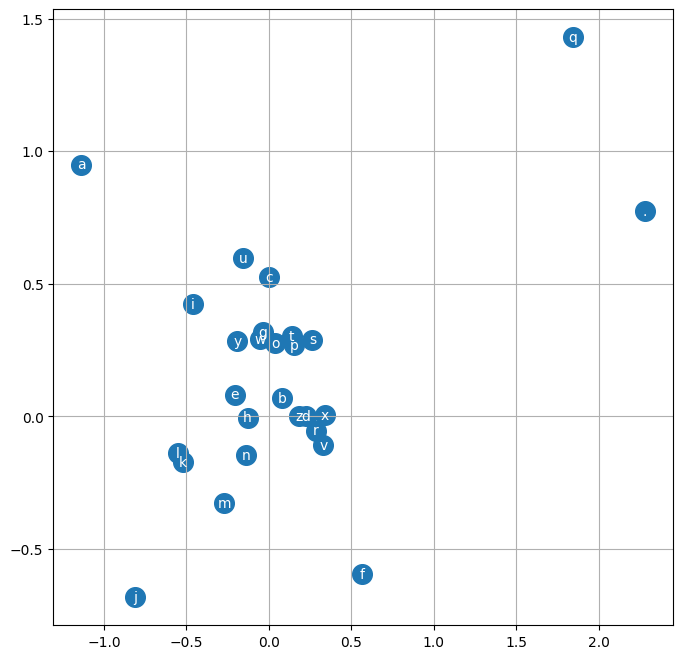

In [102]:
# Visualize the embeddings
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [ ]:
# After scaling up embedding vectors, won't be able to visualize on x, y plot

In [121]:
# Sample from the model:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # Initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carpaifati.
hari.
kimri.
reh.
cassanden.
jazonen.
delynn.
jareei.
nellara.
chaily.
kaleigh.
ham.
join.
quinn.
shon.
marianni.
wazelo.
dearyni.
jace.
pirrat.
